This code plots the energy levels of a system defined by the spin hamiltonian, consisting of some combination of the terms below:
$$H = \underbrace{\mu_{B}\times B\times g\times S}_{\textrm{Electronic Zeeman}}+\underbrace{I\times A\times S}_{hyperfine}-\underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As a note notation I refer to the hyperfine and quadrapole as the static hamiltonian with respect to the magnetic field, and the zeeman terms as the dynamic hamiltonian with respect to the magnetic field.

In [64]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr

# $Yb^{3+}:YVO_{4}$ Detailed example

The initialisation of the spin hamiltonian class calculates our spin matricies from the given electronic and nuclear spins where each matrix element is of the form:
$$J^{x}_{ij} = \frac{1}{2}(\delta_{i,j+1}+\delta_{i+1,j})\sqrt{(J+1)(i+j-1)-ij}$$
$$J^{y}_{ij} = \frac{i}{2}(\delta_{i,j+1}-\delta_{i+1,j})\sqrt{(J+1)(i+j-1)-ij}$$
$$J^{z}_{ij} = (J+1-i)\delta_{ij}$$

This is then reshaped into a $(2J+1)\times 3$ matrix where each column is made of the elements of the above matricies, in order x,y,z.

In [65]:
#spin Operators of Yb:YVO:
Espin = 1/2
Ispin = 1/2

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)
excited = spin.cSpinHamiltonian(Espin,Ispin)


Setup A tensors for the hyperfine interaction, In general these consist of a diagonal $A_{xx},A_{yy}A_{zz}$ matrix and some euler rotation around $\alpha,\beta,\gamma$ angles. For $Yb^{3+}:YVO_{4}$ there is no rotation so we use just use the diagonal matrix, but perform the zero rotation for completeness. We do not include a quadrapole interaction.

In [66]:
#A tensor ground state
A_G = np.matrix([[2.99792458e10*0.0225,0,0],[0,2.99792458e10*0.0225,0],[0,0,-2.99792458e10*0.1608]])*spin.h
#A tensor Excited state
A_E = np.matrix([[3.37e9,0,0],[0,3.37e9,0],[0,0,4.86e9]])*spin.h


#rotated tensors
A_G = spin.tensorRotation(A_G,[0,0,0])
A_E = spin.tensorRotation(A_E,[0,0,0])

Same as above for the $g$ tensor, we do not include a nuclear zeeman interaction

In [67]:
#electronic Zeeman interaction:

#g tensor ground state
g_G = np.matrix([[0.85,0,0],[0,0.85,0],[0,0,-6.08]])
#g tensor Excited state
g_E = np.matrix([[1.7,0,0],[0,1.7,0],[0,0,2.51]])



#tensor rotation
g_G = spin.tensorRotation(g_G,[0,0,0])
g_E = spin.tensorRotation(g_E,[0,0,0])

#Pass our g tensors to the class so they can be used later
ground.setgE(g_G)
excited.setgE(g_E)


As the hyperfine and quadrupole interaction terms are static with the magnetic field we calculate them outside the loop.
If either of these terms aren't needed we don't need to call these functions

In [68]:
#Pre calculate our hyperfine interactions
ground.hyperfineInteraction(A_G)
excited.hyperfineInteraction(A_E)

pass


Sets up operators for optical transition strengths, given by
$$f_{ij}\propto \left|\left<i\right|\hat{O}\left|j\right>\right|^{2}$$
The $\hat{O}$ operators are related to the crystal symmetry and are generated from character tables such as on page 32 of [2010_Powell_Symmetry, Group Theory, and the Physical Properties of Crystals](https://www.dropbox.com/home/QIL_Resources/BookSections?preview=2010_Powell_Symmetry%2C+Group+Theory%2C+and+the+Physical+Properties+of+Crystals.pdf).[^1]

For spin transitions we can use some subset of the dynamic hamiltonian.

[^1]: Link may not work but should be in the dropbox

In [69]:
odim = ground.dim//2
OS_par = np.block([[-1*np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])
OS_perp = np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])
OS_perp_T = np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])



Mainloop for each B field value the following is performed:
- The B field is converted from spherical to cartesian coordinates
- We calculate our total hamiltonian consisting of the static hyperfine and/or quadrapole and the dynamic zeeman terms.
- We calculate the eigenvalues and eigenvectors of the hamiltonian, converting the eigenvalues to frequencies.
- We calculate the transition strength between each energy level based on the eigenvectors of the excited and ground states
- We calculate the spin transition probabilities based on the dynamic hamiltonian.

In [70]:
#setup the loop, here it is easier to run the loop outside of the class
thetas = [np.pi/2]
phis = [0]
Bs=np.linspace(-0E-3,500E-3,500)
#Bs=[0]


#sets the default dynamic term as both electronic and nuclear zeeman
FreqG = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim)),dtype = np.csingle)
FreqE = np.zeros((len(thetas),len(phis),len(Bs),int(excited.dim)),dtype = np.csingle)
OS = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim**2)),dtype = np.csingle)
OS_SG = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim**2)),dtype = np.csingle)
OS_SE = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim**2)),dtype = np.csingle)

Bac = np.matrix([0,0,1]).T

#our loop
for i in range(len(thetas)):
    for j in range(len(phis)):
        for k in range(len(Bs)):
            #convert spherical Magnetic field to cartesian coords.
            B =spin.sphereCart(Bs[k],thetas[i],phis[j])
            #Calculate our hamiltonian at this B Field
            HG = ground.H+ground.electronicZeeman(B)
            #get the eigen frequencies and vectors at this B field
            FreqG[i,j,k,:],VG = ground.getEigFreq(HG)
            
            #As above for excited state
            HE = excited.H+excited.electronicZeeman(B)
            FreqE[i,j,k,:],VE = excited.getEigFreq(HE)
            
            #calculate all transition strengths
                #the optical version takes two sets of eigenvectors and an operator
            OS[i,j,k,:] = spin.TransitionStrength(VG,VE,OS_perp_T,ground.dim)
                #the spin version is tied to the class taking only one set of eigen values, and a hamiltonian operator
            OS_SG[i,j,k,:]=ground.TransitionStrength(VG,ground.electronicZeeman(Bac))
            OS_SE[i,j,k,:]=excited.TransitionStrength(VE,excited.electronicZeeman(Bac))


Plotting of energy levels for both the ground and excited state.

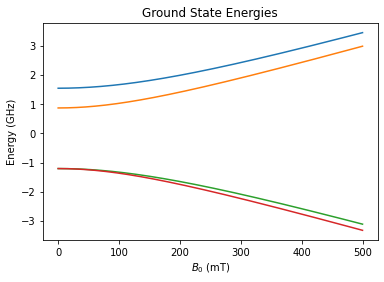

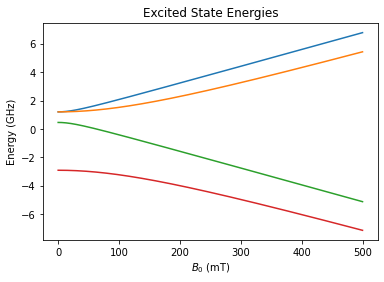

In [71]:

#Plot our energy levels
plt.plot(Bs*1E3,np.squeeze(np.real(FreqG[0,0,:,:])))
plt.title("Ground State Energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()
plt.plot(Bs*1E3,np.squeeze(np.real(FreqE[0,0,:,:])))
plt.title("Excited State Energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()

Determination of transition energies as the difference in energy level between each state and every other state.

Additionally repeats various vectors to make up larger vectors containing all optical and spin transitions.

In [72]:
#gets the transition values between each energy level
    #eachElemFunc calculates some function (default) subtraction between each of its two inputs
freq_def = np.real(spin.eachElemFunc(FreqE[0,0,:,:],FreqG[0,0,:,:],ax=1))
G_freq = np.real(spin.eachElemFunc(FreqG[0,0,:,:],FreqG[0,0,:,:],ax=1))
E_freq = np.real(spin.eachElemFunc(FreqE[0,0,:,:],FreqE[0,0,:,:],ax=1))


#Sorts our oscillator strengths to remove redundant axis
OS_s = np.real(np.squeeze(OS[0,0,:,:]))
OS_s_SG = np.squeeze(OS_SG[0,0,:,:])
OS_s_SE = np.squeeze(OS_SE[0,0,:,:])

#repeats Bstack to ensure correct dimensions for both optical and full transition plots
Bstack = np.tile(Bs,(ground.dim**2*1,1)).T
BBstack = np.tile(Bs,(ground.dim**2*3,1)).T

#stack all transitions and frequencies allowing them to be plotted together.
freq = np.hstack([freq_def,G_freq,E_freq])
OS_stack= np.real(np.hstack([OS_s,OS_s_SG,OS_s_SE]))



Nice plotting, generates a pixel value at each magnetic field and frequency coordinate based on a gaussian spread

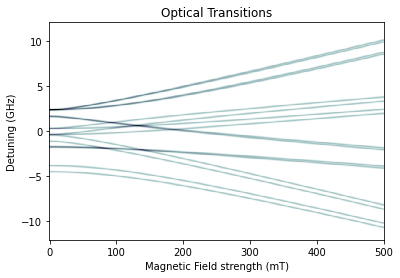

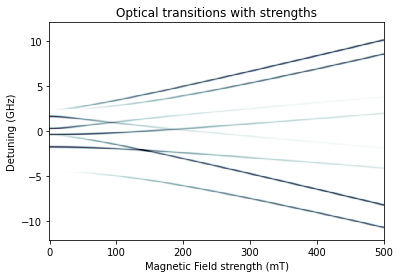

In [73]:
yi = np.linspace(-12,12,500)
cmapc = plt.cm.get_cmap('bone').copy()

spin.transitionPixelPlot(freq_def,Bs,frange=yi,width = 0.07,cmap=cmapc)
spin.transitionPixelPlot(freq_def,Bs,OS=OS_s,frange=yi,width = 0.07,cmap=cmapc,title="Optical transitions with strengths")
plt.show()
plt.close()

Alternate plotting, easier but not as nice, but much quicker.

The scatter plot uses oscillator strength as the colour value of a point



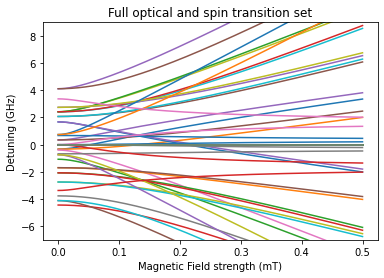

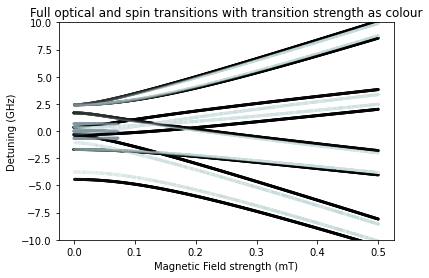

In [74]:

cmapc = plt.cm.get_cmap('bone').copy()
cmapc.set_under('k',alpha=1)

plt.plot(BBstack,freq)
plt.ylim([-7,9])
plt.title("Full optical and spin transition set")
plt.xlabel('Magnetic Field strength (mT)')
plt.ylabel('Detuning (GHz)')
plt.show()
plt.close()

plt.scatter(BBstack,freq,marker='.',c=OS_stack,edgecolors='none',norm=clr.LogNorm(),cmap=cmapc.reversed())
plt.title("Full optical and spin transitions with transition strength as colour")
plt.xlabel('Magnetic Field strength (mT)')
plt.ylabel('Detuning (GHz)')
plt.ylim([-10,10])

plt.show()
plt.close()


# $Er^{3+}:Y_{2}SiO_{5}$ example/code dump
Erbium has a few changes such as higher nuclear spin and rotated tensors, it is shown here but not walked through as nicely

A:  [[-1.56522916e+03  2.17780656e+02 -1.24459973e+02]
 [ 2.17780656e+02 -1.45016262e+01 -6.46942503e-01]
 [-1.24459973e+02 -6.46942503e-01  1.27730784e+02]]
Q:  [[-10.41919978 -23.15069052  -3.1896074 ]
 [-23.15069052 -19.62069555 -17.65555347]
 [ -3.1896074  -17.65555347  30.03989534]]
g:  [[14.36548767 -1.77124464  2.40333094]
 [-1.77124464  1.93114119 -0.42635471]
 [ 2.40333094 -0.42635471  1.43837113]]
(1, 1, 500, 256)


c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


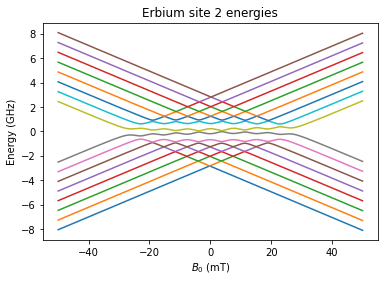

In [75]:
#Erbium parameters
Espin = 1/2
Ispin = 7/2

erbium = spin.cSpinHamiltonian(Espin,Ispin)

#Setup Hyperfine interaction tensor
A_Er = np.matrix([[139,0,0],[0,13,0],[0,0,-1604]])*spin.h*1E6 #from Jevon's group
#Get euler angles for rotation
ang_A_Er = np.array([262.2,94.07,81.9])*np.pi/180
#rotate the tensor by the euler angle
A_Er = spin.tensorRotation(A_Er,ang_A_Er,str='ZXZ')

print("A: ",A_Er/(spin.h*1E6))

#Setup quadrapole interaction tensor
Q_Er = np.matrix([[6,0,0],[0,36.1,0],[0,0,-42.1]])*spin.h*1E6 #from Jevon's group
#get the euler angles for rotation
ang_Q_Er = np.array([142.81,77.5,16.8])*np.pi/180
#rotate the tensor by the euler angles
Q_Er = spin.tensorRotation(Q_Er,ang_Q_Er,str='ZXZ')

print("Q: ",Q_Er/(spin.h*1E6))

#Get the electronic zeeman g matrix
g_Er = np.matrix([[0.99,0,0],[0,1.695,0],[0,0,15.05]]) #from Jevon's group

#Euler angles
ang_g_Er = np.array([261.98,100.16,97.25])*np.pi/180
#rotated matrix
g_Er = spin.tensorRotation(g_Er,ang_g_Er,str='ZXZ')

#get the rotation matrix for the magnetic field
RB = np.asmatrix(Rotation.from_euler('ZXZ',ang_g_Er).as_matrix())
    

print("g: ",g_Er)

#get the nuclear zeeman g matrix
gn_Er = -0.1618*np.eye(3)

#Set our nuclear and electronic g matricies
erbium.setgN(gn_Er)
erbium.setgE(g_Er)

#Pre calculate our hyperfine and quadrapole interactions
erbium.hyperfineInteraction(A_Er)
erbium.quadrupoleInteraction(Q_Er)
pass
#loop
theta,phi = spin.eulerToSphere(ang_g_Er,str='ZXZ')
thetas = [theta]
phis = [phi]
B0=np.linspace(-50E-3,50E-3,500)


dyn = lambda B: erbium.electronicZeeman(B)-erbium.nuclearZeeman(B)
FreqEr,Vs = erbium.runBfieldSweep(B0,thetas,phis,dynamic=dyn)


print(Vs.shape)


#Plot our energy
plt.plot(B0*1E3,np.squeeze(-1*FreqEr[0,0,:,:]))
plt.title("Erbium site 2 energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
#plt.savefig("erbium_Jevon.png")
plt.show()
plt.close()